# Connectomes from degrees 

In [1]:
from scipy.optimize import minimize
from scipy import stats
from scipy import linalg
import numpy as np
import functools
import networkx as nx
import tqdm
import collections
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

import graph_tool.all as gt

Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


## Negative binomial

In [2]:
def calc_var_mean(data):
    return np.var(data, ddof=1), np.mean(data)

def fit_neg_binomial(data):
    def _neg_log_likelihood(params):
        r, p = params
        if r <= 0 or not (0 < p < 1):
            return np.inf
        return -np.sum(stats.nbinom.logpmf(data, r, p))
        
    # Sample mean and variance
    var, mean = calc_var_mean(data)

    p0 = mean / var
    r0 = mean**2 / (var - mean)
    
    p0 = np.clip(p0, 1e-5, 1 - 1e-5)
    r0 = max(r0, 1e-5)
       
    result = minimize(_neg_log_likelihood, [r0, p0], bounds=[(1e-5, None), (1e-5, 1 - 1e-5)])
    r_fit, p_fit = result.x
    
    fitted_mean = r_fit * (1 - p_fit) / p_fit
    fitted_var = r_fit * (1-p_fit) / p_fit**2
    fitted_var_over_mean = fitted_var / fitted_mean
    
    print(f"Fitted Negative Binomial Parameters: r = {r_fit:.3f}, p = {p_fit:.3f}")
    print(f"Fitted mean: {fitted_mean:.3f}")
    print(f"Fitted var: {fitted_var:.3f}")
    print(f"Fitted var/mean: {fitted_var_over_mean:.3f}")

    return r_fit, p_fit

def r_from_p(p, m):
    return p / (1-p) * m

def var_from_r_p(r, p):
    return r * (1-p) / p**2

def mean_from_r_p(r, p):
    return r * (1 - p) / p

def sample_from_neg_binomial(r, p, n_samples, eps=1e-6):
    samples = stats.nbinom.rvs(r, p, size=n_samples)
    if eps is not None:
        target_sum = r * (1 - p) / p * n_samples
        while abs(1-np.sum(samples) / target_sum) > eps:
            samples = stats.nbinom.rvs(r, p, size=n_samples)
    return samples

def sample_from_neg_binomial_var_mean(v, m, n_samples, eps=1e-6):
    p = 1. / (v / m)
    r = r_from_p(p, m)

    return sample_from_neg_binomial(r, p, n_samples, eps=eps)

## Schur

In [3]:
def feedforward_ratio(g, complex_decomp=True):
    """ Computes the Schur decomposition and ff-ratio of a square matrix A

    Parameters:
        g: nx graph
        complex_decomp: if True, use complex Schur; else real Schur

    Returns:
        ff_ratio: fraction of Frobenius norm above the diagonal in T
        T: the Schur form of A (upper triangular)
        Q: the unitary/orthogonal basis matrix
    """
    A = nx.to_numpy_array(g, dtype=float)

    if not np.all(np.isfinite(A)):
        return np.nan, np.zeros_like(A), np.zeros_like(A)

    if A.shape[0] != A.shape[1]:
        return np.nan, np.zeros_like(A), np.zeros_like(A)

    if A.shape[0] == 1:
        return 0, np.array([[0]]), np.array([[1]])

    try:
        T, Q = linalg.schur(A, output="complex" if complex_decomp else "real")
    except np.linalg.LinAlgError:
        return np.nan, np.zeros_like(A), np.zeros_like(A)

    total_norm_sq = np.linalg.norm(T, "fro") ** 2

    upper_tri_mask = np.triu(np.ones_like(T), k=1)
    upper_norm_sq = np.sum(np.abs(T * upper_tri_mask) ** 2)

    ff_ratio = upper_norm_sq / total_norm_sq if total_norm_sq > 0 else 0

    return ff_ratio, T, Q


def henrici_departure(A):
    """Henrici’s departure from normality"""
    fro_norm_sq = np.linalg.norm(A, ord="fro") ** 2
    eig_norm_sq = np.sum(np.abs(linalg.eigvals(A)) ** 2)
    return np.sqrt(fro_norm_sq - eig_norm_sq.real) / np.linalg.norm(A, ord="fro")

## Parameter sets

In [4]:
param_sets = {
    "L4_wot": {
        "n_neurons": 306,
        "n_connections": 3915,
        "var_in_fit": 62.45,
        "var_out_fit": 53.34,
    },
    "L4_wt": {
        "n_neurons": 306,
        "n_connections": 1566,
        "var_in_fit": 12.576,
        "var_out_fit": 15.927,
    }
}

for k in param_sets:
    param_sets[k]["mean"] = param_sets[k]["n_connections"] / param_sets[k]["n_neurons"]

In [5]:
param_sets

{'L4_wot': {'n_neurons': 306,
  'n_connections': 3915,
  'var_in_fit': 62.45,
  'var_out_fit': 53.34,
  'mean': 12.794117647058824},
 'L4_wt': {'n_neurons': 306,
  'n_connections': 1566,
  'var_in_fit': 12.576,
  'var_out_fit': 15.927,
  'mean': 5.117647058823529}}

## Sampling connectomes - example

In [7]:
param_set = param_sets["L4_wt"]

param_set["var_in_fit"] = 5.25
param_set["var_out_fit"] = 5.25

In [8]:
def degree_sampler(idx, in_, out_):
    return (in_[idx], out_[idx])

# Sample degrees
sampled_in_degrees = sample_from_neg_binomial_var_mean(param_set["var_in_fit"], param_set["mean"], param_set["n_neurons"])
sampled_out_degrees = sample_from_neg_binomial_var_mean(param_set["var_out_fit"], param_set["mean"], param_set["n_neurons"])

# Sample graph
degree_sampler_instantiated = functools.partial(degree_sampler, in_=sampled_in_degrees, out_=sampled_out_degrees)
g_gt = gt.random_graph(param_set["n_neurons"], degree_sampler_instantiated, verbose=False)
sampled_edges = np.array([[int(e.source()), int(e.target())] for e in g_gt.edges()])

# Scoring
g_nx = nx.DiGraph()
g_nx.add_edges_from(sampled_edges)
ff_ratio = feedforward_ratio(g_nx)[0]
henricis = henrici_departure(nx.to_numpy_array(g_nx, dtype=float))

ff_ratio, henricis

(np.float64(0.5373904989240498), np.float64(0.7330692320129456))

## Sampling connectomes - across variances

$var_{in} = var_{out}$

In [9]:
param_set = param_sets["L4_wt"]

In [10]:
var_over_means = np.linspace(1, 4, 20)
var_over_means[var_over_means == 1] += 1e-4 # var_over_mean has to be > 1

data_coll = collections.defaultdict(list)
for var_over_mean in tqdm.tqdm(var_over_means):
    for _ in range(10):
        # Sample degrees
        sampled_in_degrees = sample_from_neg_binomial_var_mean(var_over_mean * param_set["mean"], param_set["mean"], param_set["n_neurons"])
        sampled_out_degrees = sample_from_neg_binomial_var_mean(var_over_mean * param_set["mean"], param_set["mean"], param_set["n_neurons"])
        
        # Sample graph
        degree_sampler_instantiated = functools.partial(degree_sampler, in_=sampled_in_degrees, out_=sampled_out_degrees)
        g_gt = gt.random_graph(param_set["n_neurons"], degree_sampler_instantiated, verbose=False)
        sampled_edges = np.array([[int(e.source()), int(e.target())] for e in g_gt.edges()])
        
        # Scoring
        g_nx = nx.DiGraph()
        g_nx.add_edges_from(sampled_edges)
        ff_ratio = feedforward_ratio(g_nx)[0]
        henricis = henrici_departure(nx.to_numpy_array(g_nx, dtype=float))

        data_coll["var_over_mean"].append(var_over_mean)
        data_coll["ff_ratio"].append(ff_ratio)
        data_coll["henricis"].append(henricis)

sample_df = pd.DataFrame(data_coll)

100%|██████████| 20/20 [00:43<00:00,  2.20s/it]


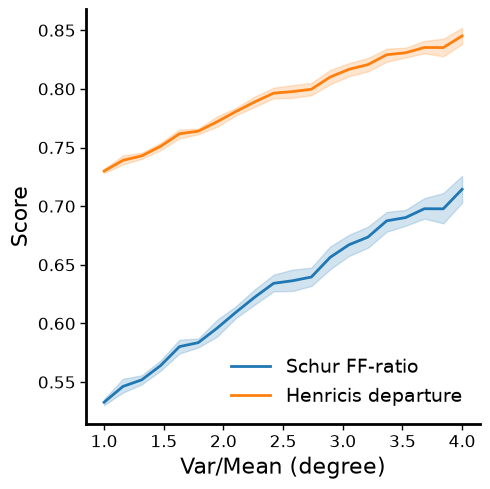

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.lineplot(data=sample_df, x="var_over_mean", y="ff_ratio", label="Schur FF-ratio", lw=2)
sns.lineplot(data=sample_df, x="var_over_mean", y="henricis", label="Henricis departure", lw=2)
ax.legend(frameon=False, fontsize=14)

ax.set_xlabel("Var/Mean (degree)", fontsize=16)
ax.set_ylabel("Score", fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=12, width=1, length=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)


plt.tight_layout()
plt.show()

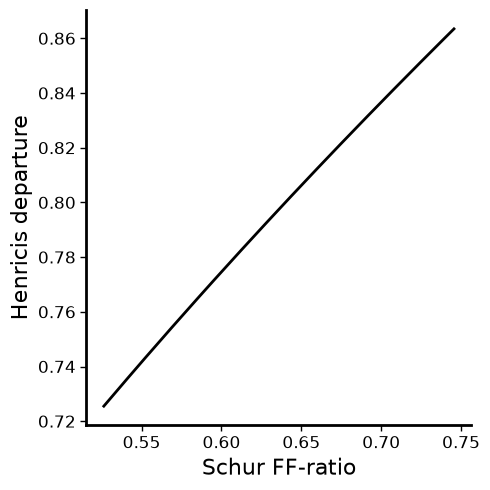

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.lineplot(data=sample_df, x="ff_ratio", y="henricis", c="k", lw=2)

ax.set_xlabel("Schur FF-ratio", fontsize=16)
ax.set_ylabel("Henricis departure", fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=12, width=1, length=4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)


plt.tight_layout()
plt.show()